# Viabilidad de un buffet de sushi en Madrid
**Peng Chen — análisis de escenarios, 13/09/2026**

Pregunta: ¿qué demanda mínima exige una estructura de precio y costes? Todos los parámetros comerciales son **supuestos ilustrativos no calibrados**. No hay probabilidades asignadas a los escenarios ni una predicción de ventas. Véanse FASE4_RESULTADOS.md y FASE5_RESULTADOS.md.

El ticket incluye bebidas e IVA; se convierte a ingreso neto. El resultado excluye amortización, financiación e impuestos sobre beneficios. No mide recuperación de inversión.

In [1]:
from pathlib import Path
import json, sys
BASE = Path.cwd()
if not (BASE / 'modelo_viabilidad.py').exists():
    BASE = BASE / 'investigacion_madrid'
assert (BASE / 'modelo_viabilidad.py').exists(), 'Ejecutar desde TFM o investigacion_madrid'
sys.path.insert(0, str(BASE))
from modelo_viabilidad import generar
import pandas as pd
config = json.loads((BASE / 'supuestos_viabilidad.json').read_text())
print(config['advertencia'])
pd.DataFrame(config['escenarios']).T

TODOS los parámetros comerciales son supuestos ilustrativos sin calibrar, no datos observados de una apertura. IVA de restauración: referencia AEAT; no modela liquidaciones fiscales.


,ticket_bruto,iva,ratio_alimentos,variable_extra,dias,asientos,servicios,rotaciones,ocupacion,fijos
tension,22,0.1,0.46,1,26,60,2,1,0.4,"{'alquiler': 3000, 'personal_coste_empresa': 1..."
referencia,26,0.1,0.38,1,26,60,2,1,0.6,"{'alquiler': 3000, 'personal_coste_empresa': 1..."
favorable,30,0.1,0.3,1,26,60,2,1,0.75,"{'alquiler': 3000, 'personal_coste_empresa': 1..."


In [2]:
resultados = generar()
tabla = pd.DataFrame(resultados['escenarios']).T
tabla[['margen_cliente','fijos_mes','umbral_clientes_dia','ocupacion_equilibrio','resultado_operativo_mes']].round(2)

,margen_cliente,fijos_mes,umbral_clientes_dia,ocupacion_equilibrio,resultado_operativo_mes
tension,9.8,21000,82.417582,0.686813,-8769.6
referencia,13.654545,21000,59.1519,0.492933,4561.309091
favorable,18.090909,21000,44.646308,0.372053,21332.727273


## Sensibilidad manteniendo constantes capacidad y costes fijos
Se varían ticket total (22, 26, 30 €) y coste de alimentos, bebidas y mermas (30%, 38%, 46% del ingreso neto). Estos intervalos no son estadísticas del sector. Cada celda muestra clientes diarios necesarios. La ocupación media oculta diferencias entre servicios y días.

In [3]:
s = pd.DataFrame(resultados['sensibilidad'])
s.pivot(index='ratio_alimentos', columns='ticket_bruto', values='umbral_clientes_dia').round(1)

ticket_bruto,22,26,30
ratio_alimentos,,,
0.30,62.1,52.0,44.6
0.38,70.9,59.2,50.8
0.46,82.4,68.7,58.8


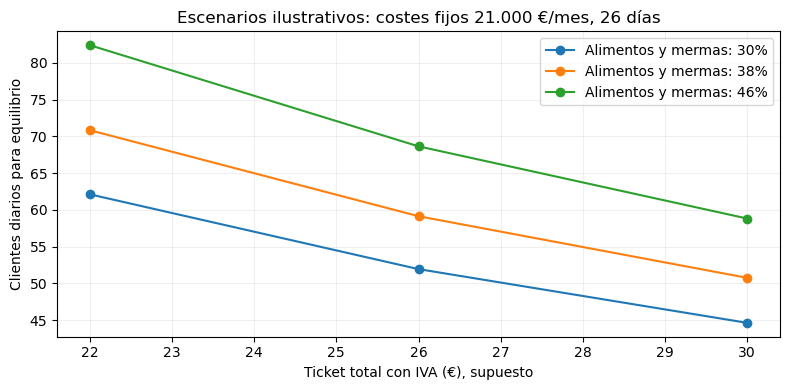

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
for ratio, grupo in s.groupby('ratio_alimentos'):
    ax.plot(grupo.ticket_bruto, grupo.umbral_clientes_dia, marker='o', label=f'Alimentos y mermas: {ratio:.0%}')
ax.set(xlabel='Ticket total con IVA (€), supuesto', ylabel='Clientes diarios para equilibrio', title='Escenarios ilustrativos: costes fijos 21.000 €/mes, 26 días')
ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
fig.savefig(BASE / 'sensibilidad_viabilidad.png', dpi=160)
plt.show()

## Interpretación y límites
Un resultado operativo positivo no implica inversión rentable: faltan traspaso, obra, equipos, financiación, amortización y liquidez del arranque. No se vincula el supuesto de 60 plazas a ninguno de los locales anunciados. La capacidad debe verificarse con distribución, aforo, cocina y plantilla.

Para validar: escandallos y desperdicio, presupuesto de plantilla y turnos, local concreto, composición de ventas por servicio, observaciones repetidas de afluencia e inversión inicial. No convertir renta residencial ni reseñas en clientes mediante coeficientes inventados.

Fuente fiscal: [AEAT, manual IVA 2025](https://sede.agenciatributaria.gob.es/Sede/ayuda/25manual/IVA.html). El modelo usa 10% para restauración ordinaria; no calcula liquidaciones de IVA.